In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add src to path for lcgen imports
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from torch.utils.data import DataLoader
from lcgen.models.simple_min_gru import BiDirectionalMinGRU
from lcgen.models.TimeSeriesDataset import TimeSeriesDataset, collate_fn

## Configuration

Edit these parameters to match your model and desired output.

In [3]:
# ============== CONFIGURATION ==============
# Model settings
MODEL_PATH = Path.cwd().parent / 'output/simple_rnn/models/baseline_v17_real_final.pt'
HIDDEN_SIZE = 64
DIRECTION = 'bi'  # 'forward', 'backward', or 'bi'
MODE = 'parallel'  # 'sequential' or 'parallel'
USE_FLOW = True
FLOW_MODE = 'mean'  # 'mean', 'mode', or 'sample'

# Data settings
DATA_PATH = Path.cwd().parent / 'data/timeseries.h5'
SEQ_LENGTH = 1024
MIN_SIZE = 5
MAX_SIZE = 100
MASK_PORTION = 0.3

# Plotting settings
RANDOM_SEED = 69
LAGS = [1, 8, 32]  # Which t-k predictions to plot

# ============================================

## Load Model

In [4]:
# Set random seeds
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = BiDirectionalMinGRU(
    hidden_size=HIDDEN_SIZE, 
    direction=DIRECTION, 
    mode=MODE, 
    use_flow=USE_FLOW
).to(device)

ckpt = torch.load(MODEL_PATH, map_location=device)
if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    sd = ckpt['model_state_dict']
else:
    sd = ckpt

model.load_state_dict(sd)
model.eval()
print(f'Loaded model from {MODEL_PATH}')
print(f'Flow head enabled: {model.flow is not None}')

Using device: cpu
Loaded model from /Users/philvanlane/Documents/lc_ae/output/simple_rnn/models/baseline_v17_real_final.pt
Flow head enabled: True


## Load Data and Generate Reconstruction

In [5]:
# Load a single random lightcurve
ds = TimeSeriesDataset(
    DATA_PATH, 
    random_seed=RANDOM_SEED, 
    min_size=MIN_SIZE, 
    max_size=MAX_SIZE, 
    mask_portion=MASK_PORTION, 
    max_length=SEQ_LENGTH, 
    num_samples=1
)
loader = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
batch_X = next(iter(loader))
flux, flux_err, times, mask = batch_X
flux = flux.to(device)
flux_err = flux_err.to(device)
times = times.to(device)
mask = mask.to(device)

print(f'Loaded lightcurve with {flux.shape[1]} timesteps')
print(f'Masked fraction: {(mask == 0).float().mean().item():.2%}')

Truncated data to max_length=1024, kept 1/7911 samples.
Loaded lightcurve with 1024 timesteps
Masked fraction: 25.59%


## Run Model and Compute Multi-Horizon Predictions

In [6]:
# Build input channels [flux, flux_err] -> (B, L, 2)
x_in = torch.stack([flux, flux_err], dim=-1)
t_in = torch.stack([times], dim=-1)

# Run model
with torch.no_grad():
    out = model(x_in, t_in, mask=mask, return_states=True, flow_mode=FLOW_MODE)

# Extract outputs
recon = out['reconstructed']
mean = recon[..., 0]
h_fwd = out.get('h_fwd_tensor')
h_bwd = out.get('h_bwd_tensor')

# Compute time encodings
with torch.no_grad():
    t_seq = t_in.squeeze(-1)
    t0 = t_seq[:, 0].unsqueeze(1)
    t_shifted = (t_seq - t0).unsqueeze(-1)
    t_enc_in = model.time_enc(t_shifted)

# Convert to numpy for plotting
flux_np = flux.cpu().numpy()
flux_err_np = flux_err.cpu().numpy()
times_np = times.cpu().numpy()
mean_np = mean.cpu().numpy()
mask_np = mask.cpu().numpy()

print('Model inference complete')

Model inference complete


In [68]:
def compute_lagged_predictions(model, h_fwd, h_bwd, t_enc_in, flux_err, lags, flow_mode='mean', n_samples=32):
    """
    Compute predictions from lagged hidden states (t-k predictions) with SYMMETRIC offsets.
    
    For bidirectional models, predicts position j using:
    - Forward hidden at j-k (info from 0 to j-k-1)
    - Backward hidden at j+k (info from j+k+1 to L-1)
    
    This ensures neither direction sees any data within k steps of the target.
    Valid prediction range: positions k to L-1-k
    
    Returns:
        preds_ks: dict mapping lag k -> (B, L) array of mean predictions
        preds_ks_p16: dict mapping lag k -> (B, L) array of 16th percentile
        preds_ks_p84: dict mapping lag k -> (B, L) array of 84th percentile
    """
    device = h_fwd.device
    B, L, H = h_fwd.shape
    Te = t_enc_in.size(-1)
    flow_head = getattr(model, 'flow', None)
    head = model.gauss_head
    
    preds_ks = {}
    preds_ks_p16 = {}
    preds_ks_p84 = {}
    
    with torch.no_grad():
        for k in lags:
            preds_k = torch.full((B, L), float('nan'), device=device)
            preds_p16 = None
            preds_p84 = None
            
            # Symmetric offset: need 2*k < L for valid predictions
            if 2*k >= L:
                preds_ks[k] = preds_k.cpu().numpy()
                continue
                
            n_targets = L - 2*k  # number of valid target positions
            
            # Bidirectional: combine forward hidden at j-k and backward hidden at j+k
            if h_bwd is not None:
                # Forward hidden at positions 0 to n_targets-1 (for targets k to L-1-k)
                src_f = h_fwd[:, :n_targets, :]
                # Backward hidden at positions 2*k to L-1 (for targets k to L-1-k)
                src_b = h_bwd[:, 2*k:, :]
                # Time encoding at target positions k to L-1-k
                tgt = t_enc_in[:, k:L-k, :]
                inputs_k = torch.cat([src_f, src_b, tgt], dim=-1)
            else:
                src = h_fwd[:, :n_targets, :]
                tgt = t_enc_in[:, k:L-k, :]
                inputs_k = torch.cat([src, tgt], dim=-1)
            
            flat_in = inputs_k.contiguous().view(-1, inputs_k.size(-1))
            
            # Apply head normalization and time scaling
            normed = model.head_norm(flat_in)
            nt = Te
            if nt > 0:
                h_hidden = normed[:, :-nt]
                h_time = normed[:, -nt:] * model.time_scale
                normed = torch.cat([h_hidden, h_time], dim=1)
            
            # Get flux error at target positions
            ferr_tgt = flux_err[:, k:L-k]
            ferr_flat = ferr_tgt.contiguous().view(-1, 1)
            
            if flow_head is not None:
                ctx = torch.cat([normed, ferr_flat], dim=1)
                dist = flow_head(ctx)
                
                if flow_mode == 'sample':
                    flat_preds = dist.sample().view(B, n_targets)
                elif flow_mode == 'mode':
                    # Gradient-based mode finding
                    y_init = dist.sample().clone()
                    y_opt = y_init.requires_grad_(True)
                    optimizer = torch.optim.Adam([y_opt], lr=0.1)
                    for _ in range(50):
                        optimizer.zero_grad()
                        loss = -dist.log_prob(y_opt).sum()
                        loss.backward()
                        optimizer.step()
                        with torch.no_grad():
                            y_opt.clamp_(-10, 10)
                    flat_preds = y_opt.detach().view(B, n_targets)
                else:  # 'mean'
                    samples = torch.stack([dist.sample() for _ in range(n_samples)], dim=0)
                    samples = samples.squeeze(-1).view(n_samples, B, n_targets)
                    flat_preds = samples.mean(dim=0)
                    preds_p16 = torch.quantile(samples, 0.16, dim=0)
                    preds_p84 = torch.quantile(samples, 0.84, dim=0)
            else:
                flat_preds = head(normed).view(B, n_targets)
            
            # Store predictions at target positions k to L-1-k
            preds_k[:, k:L-k] = flat_preds
            
            # Store percentiles if computed
            if preds_p16 is not None:
                preds_k_p16 = torch.full((B, L), float('nan'), device=device)
                preds_k_p84 = torch.full((B, L), float('nan'), device=device)
                preds_k_p16[:, k:L-k] = preds_p16
                preds_k_p84[:, k:L-k] = preds_p84
                preds_ks_p16[k] = preds_k_p16.cpu().numpy()
                preds_ks_p84[k] = preds_k_p84.cpu().numpy()
            
            preds_ks[k] = preds_k.cpu().numpy()
    
    return preds_ks, preds_ks_p16, preds_ks_p84

# Compute predictions for all lags
preds_ks, preds_ks_p16, preds_ks_p84 = compute_lagged_predictions(
    model, h_fwd, h_bwd, t_enc_in, flux_err, LAGS, flow_mode=FLOW_MODE
)

print(f'Computed predictions for lags: {LAGS}')

Computed predictions for lags: [1, 8, 32]


## Helper Function for Masked Intervals

In [69]:
def mask_intervals(mask_1d):
    """Given a boolean array where True = masked, return list of (start, end) intervals."""
    masked = mask_1d.astype(bool)
    L = len(masked)
    intervals = []
    in_block = False
    start = None
    
    for i in range(L):
        if masked[i] and not in_block:
            in_block = True
            start = i
        elif not masked[i] and in_block:
            in_block = False
            intervals.append((start, i))
    if in_block:
        intervals.append((start, L))
    return intervals

## Plot Reconstruction

Edit the plotting parameters below to customize the figure.

In [70]:
# ============== PLOT CONFIGURATION ==============
FIGWIDTH = 15
FIGHEIGHT = 8
DPI = 150

# Colors
DATA_COLOR = 'black'
DATA_ALPHA = 0.5
ERROR_COLOR = 'lightgray'
MASK_COLOR = 'red'
MASK_ALPHA = 0.15

# Line styles
PRED_LINEWIDTH = 2
PERCENTILE_LINEWIDTH = 1
PERCENTILE_ALPHA = 0.7

# Font sizes
TITLE_FONTSIZE = 14
LABEL_FONTSIZE = 12
LEGEND_FONTSIZE = 10

# ================================================

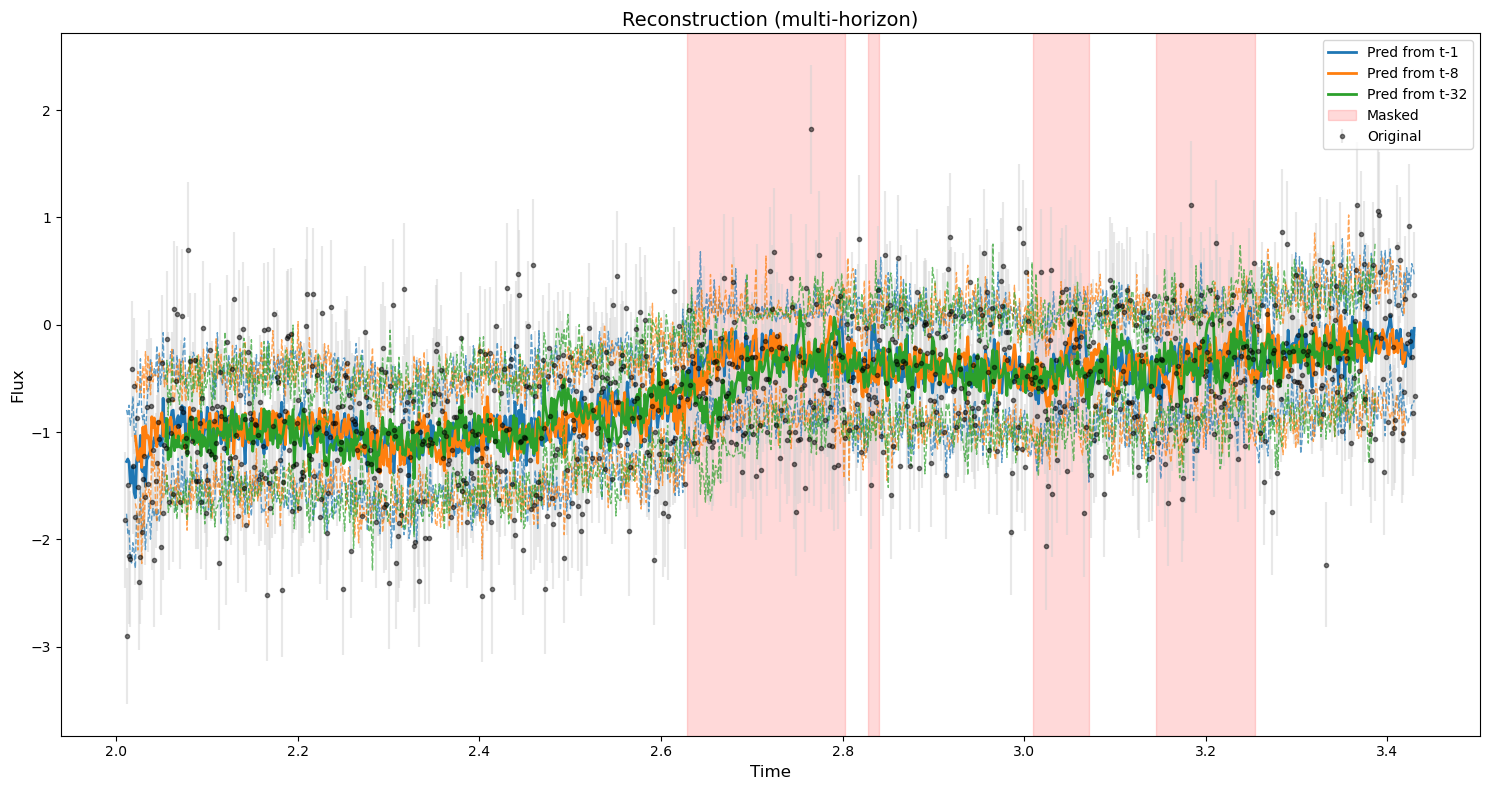

In [71]:
# Get masked intervals
masked_positions = (mask_np[0] == 0)
intervals = mask_intervals(masked_positions)

# Create figure
fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGHEIGHT))

# Plot original data with errorbars
ax.errorbar(
    times_np[0], flux_np[0], yerr=flux_err_np[0], 
    fmt='.', label='Original', alpha=DATA_ALPHA, 
    color=DATA_COLOR, ecolor=ERROR_COLOR
)

# Plot predictions for each lag
cmap = plt.get_cmap('tab10')
for idx, k in enumerate(LAGS):
    pred_k = preds_ks.get(k)
    if pred_k is None:
        continue
    
    color = cmap(idx % 10)
    
    # Mean prediction as solid line
    ax.plot(
        times_np[0], pred_k[0], 
        label=f'Pred from t-{k}', 
        color=color, linestyle='-', linewidth=PRED_LINEWIDTH
    )
    
    # Plot 16th and 84th percentiles as dashed lines
    pred_p16 = preds_ks_p16.get(k)
    pred_p84 = preds_ks_p84.get(k)
    if pred_p16 is not None and pred_p84 is not None:
        ax.plot(
            times_np[0], pred_p16[0], 
            color=color, linestyle='--', 
            linewidth=PERCENTILE_LINEWIDTH, alpha=PERCENTILE_ALPHA
        )
        ax.plot(
            times_np[0], pred_p84[0], 
            color=color, linestyle='--', 
            linewidth=PERCENTILE_LINEWIDTH, alpha=PERCENTILE_ALPHA
        )

# Highlight masked regions
for start, end in intervals:
    x0 = times_np[0, start]
    x1 = times_np[0, end-1] if end > start else x0
    ax.axvspan(
        x0, x1, color=MASK_COLOR, alpha=MASK_ALPHA, 
        label='Masked' if start == intervals[0][0] else None
    )

ax.set_title('Reconstruction (multi-horizon)', fontsize=TITLE_FONTSIZE)
ax.set_xlabel('Time', fontsize=LABEL_FONTSIZE)
ax.set_ylabel('Flux', fontsize=LABEL_FONTSIZE)
ax.legend(fontsize=LEGEND_FONTSIZE)

plt.tight_layout()
plt.show()

## Try Different Random Seeds

Change the seed below to see different lightcurves.

In [72]:
def plot_reconstruction_for_seed(seed, color='goldenrod', lags=LAGS, flow_mode=FLOW_MODE,
                                 min_size=MIN_SIZE, max_size=MAX_SIZE,mask_portion=MASK_PORTION):
    """Load a lightcurve with a specific seed and plot its reconstruction."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Load data
    ds = TimeSeriesDataset(
        DATA_PATH, random_seed=seed, min_size=min_size, max_size=max_size,
        mask_portion=mask_portion, max_length=SEQ_LENGTH, num_samples=1
    )
    loader = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
    flux, flux_err, times, mask = next(iter(loader))
    flux, flux_err, times, mask = flux.to(device), flux_err.to(device), times.to(device), mask.to(device)
    
    # Run model
    x_in = torch.stack([flux, flux_err], dim=-1)
    t_in = torch.stack([times], dim=-1)
    
    with torch.no_grad():
        out = model(x_in, t_in, mask=mask, return_states=True, flow_mode=flow_mode)
    
    h_fwd = out.get('h_fwd_tensor')
    h_bwd = out.get('h_bwd_tensor')
    
    # Compute time encodings
    t_seq = t_in.squeeze(-1)
    t0 = t_seq[:, 0].unsqueeze(1)
    t_shifted = (t_seq - t0).unsqueeze(-1)
    with torch.no_grad():
        t_enc = model.time_enc(t_shifted)
    
    # Compute predictions
    preds, p16, p84 = compute_lagged_predictions(model, h_fwd, h_bwd, t_enc, flux_err, lags, flow_mode=flow_mode)
    
    # Convert to numpy
    flux_np = flux.cpu().numpy()
    flux_err_np = flux_err.cpu().numpy()
    times_np = times.cpu().numpy()
    mask_np = mask.cpu().numpy()
    
    # Plot
    masked_positions = (mask_np[0] == 0)
    intervals = mask_intervals(masked_positions)
    
    fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGHEIGHT))
    
    times_rel = times_np[0] - times_np[0, 0]
    ax.errorbar(times_rel, flux_np[0], yerr=flux_err_np[0], fmt='.', 
                markersize=8,
                label='Original', alpha=DATA_ALPHA, color=DATA_COLOR, ecolor=ERROR_COLOR)
    
    cmap = plt.get_cmap('tab10')
    first_fill = True  # Track if this is the first fill_between for legend
    for idx, k in enumerate(lags):
        pred_k = preds.get(k)
        if pred_k is None:
            continue
        # color = cmap(idx % 10)
        ax.plot(times_rel, pred_k[0], label=f'Reconstruction (offset {k})', color=color,
                linewidth=PRED_LINEWIDTH)
        pred_p16 = p16.get(k)
        pred_p84 = p84.get(k)
        if pred_p16 is not None and pred_p84 is not None:
            # Shaded region between 16th and 84th percentiles
            fill_label = r'1$\sigma$ credible interval' if first_fill else None
            ax.fill_between(times_rel, pred_p16[0], pred_p84[0], color=color, alpha=0.3, label=fill_label)
            first_fill = False
    
    for start, end in intervals:
        x0 = times_rel[start]
        x1 = times_rel[end-1] if end > start else x0
        ax.axvspan(x0, x1, color=MASK_COLOR, alpha=MASK_ALPHA, label='Masked' if start == intervals[0][0] else None)
    
    # ax.set_title(f'Reconstruction (seed={seed})', fontsize=TITLE_FONTSIZE)
    ax.set_xlabel('Relative Time (d)', fontsize=20)
    ax.set_ylabel('Normalized Flux', fontsize=20)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
    ax.set_xlim(times_rel[0], times_rel[-1])
    ax.legend(fontsize=16)
    plt.tight_layout()
    plt.show()

Truncated data to max_length=1024, kept 1/7911 samples.


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


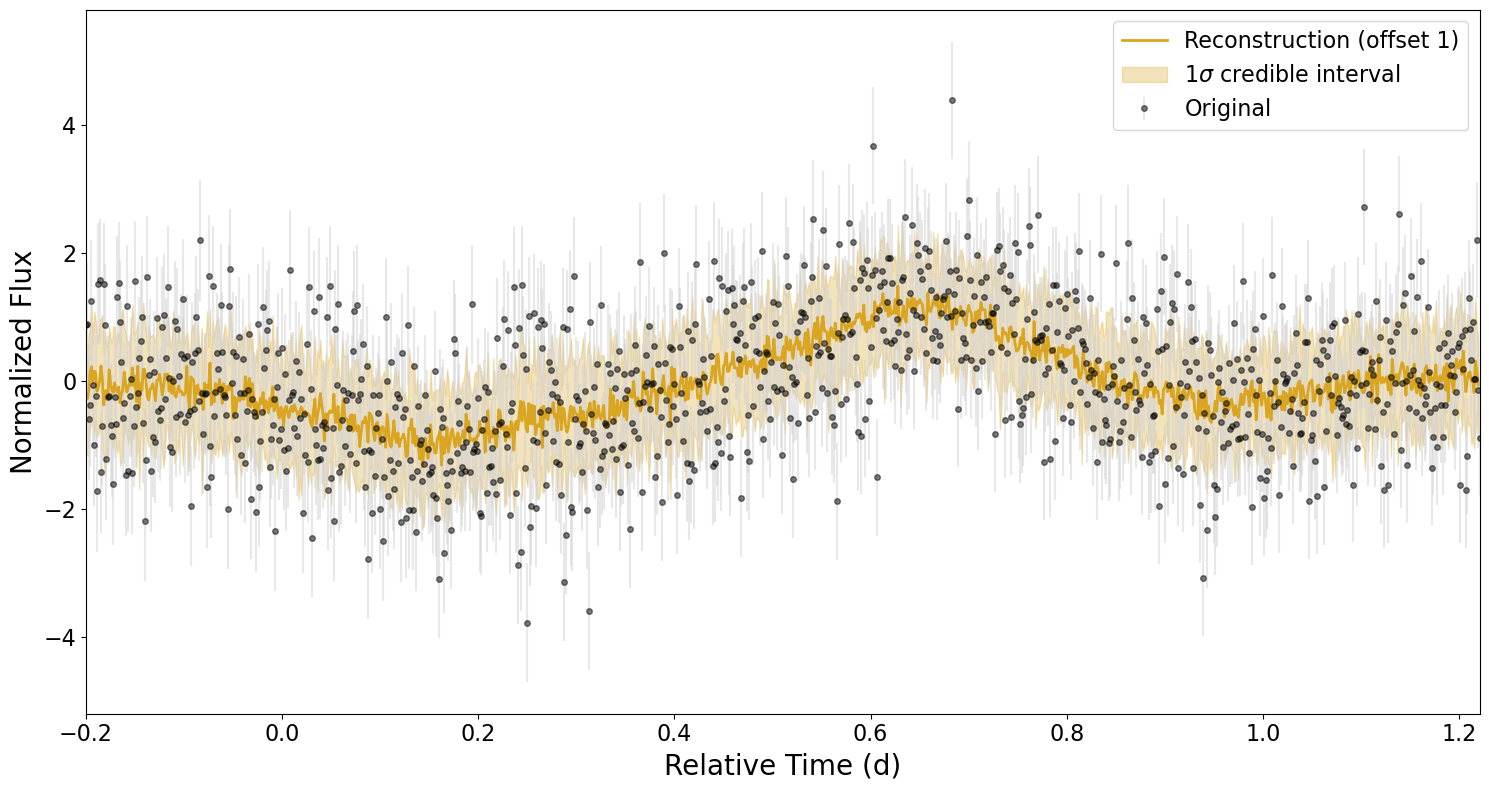

In [73]:

# Try a different seed
plot_reconstruction_for_seed(2,color='goldenrod',lags=[1],mask_portion=0)

Truncated data to max_length=1024, kept 1/7911 samples.


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


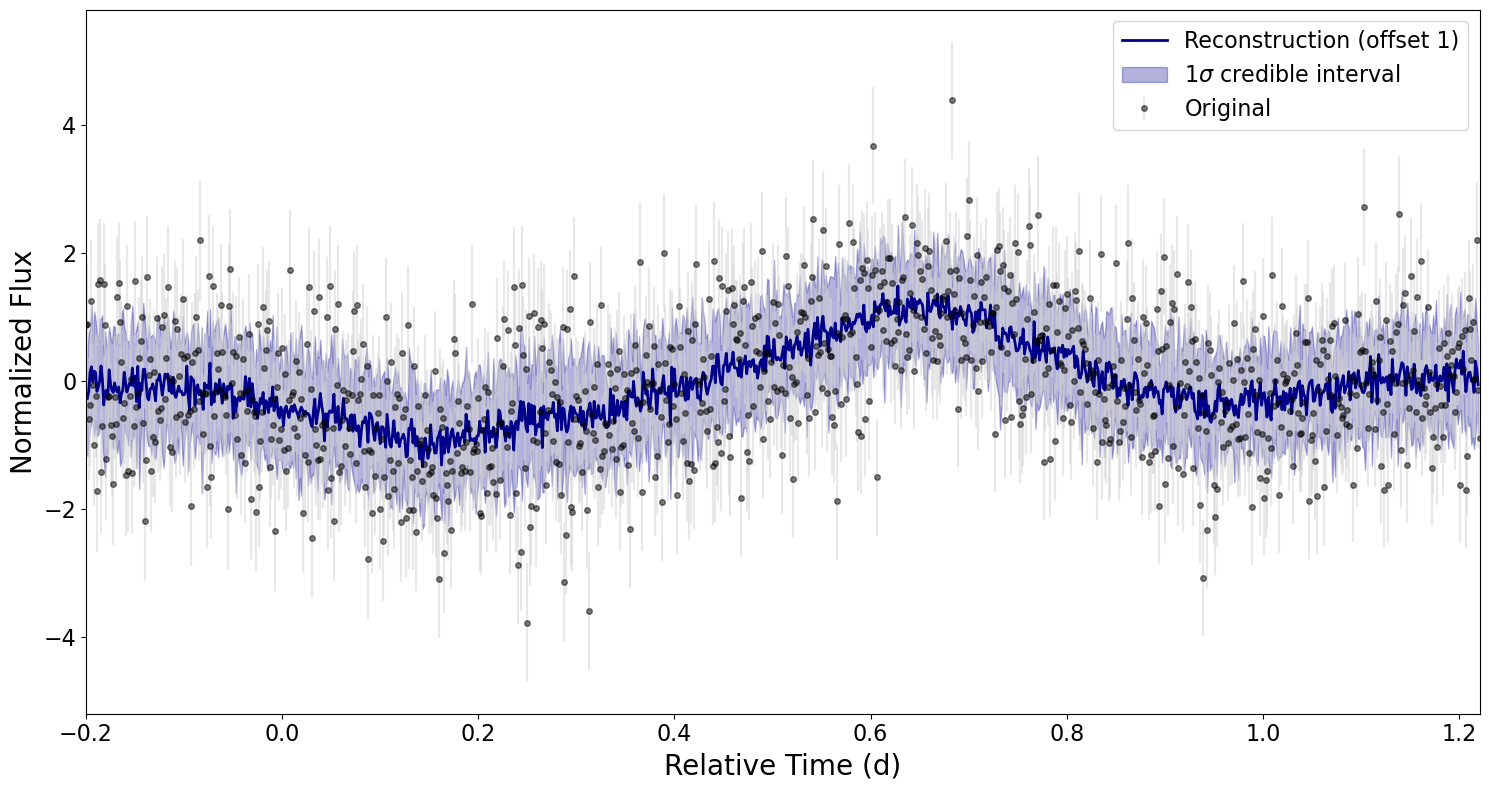

In [174]:

# Try a different seed
plot_reconstruction_for_seed(2,color='darkblue',lags=[1],mask_portion=0)

Truncated data to max_length=1024, kept 1/7911 samples.


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


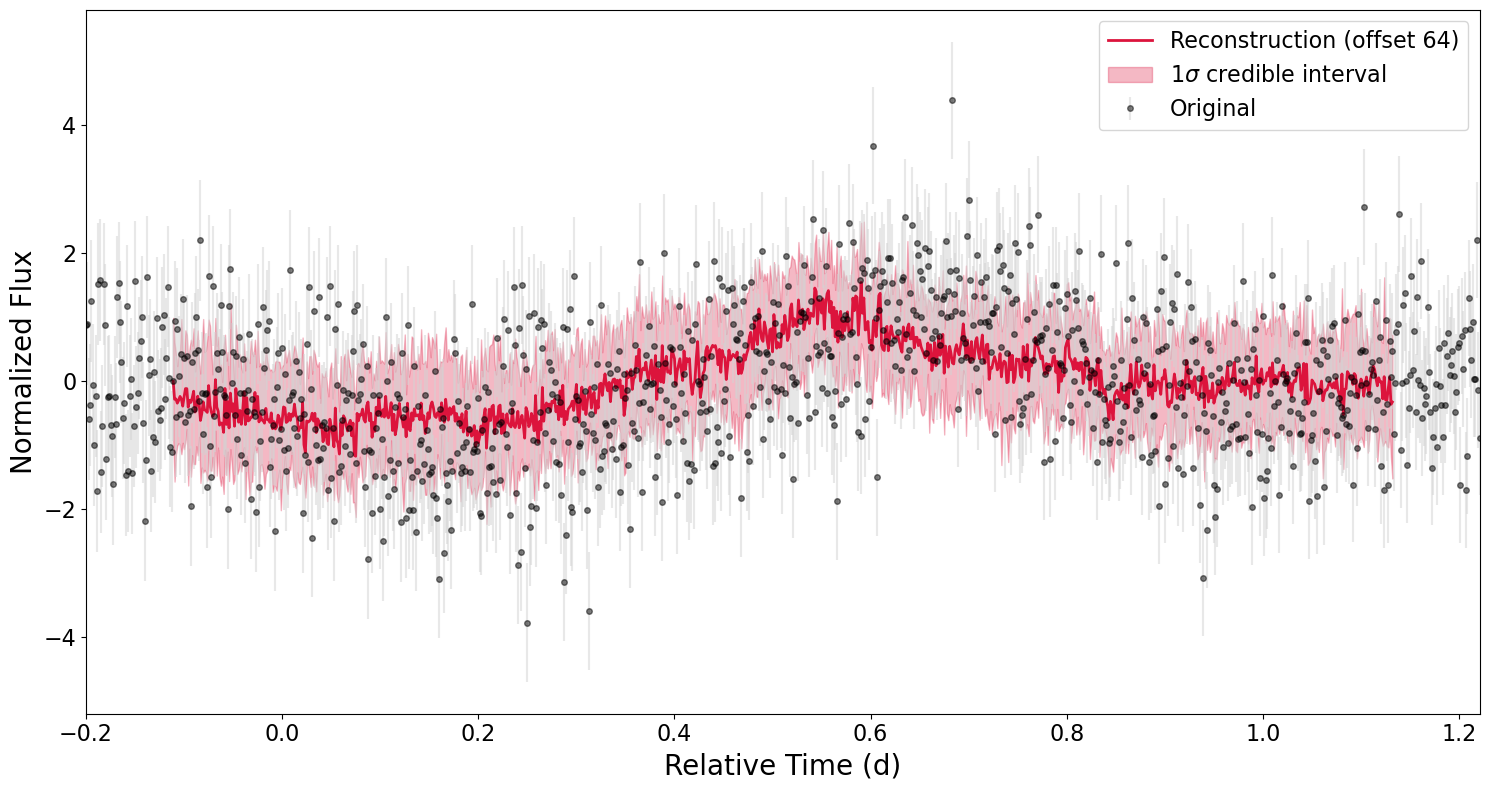

In [74]:

# Try a different seed
plot_reconstruction_for_seed(2,color='crimson',lags=[64],mask_portion=0)

Truncated data to max_length=1024, kept 1/7911 samples.


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/1677635558.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


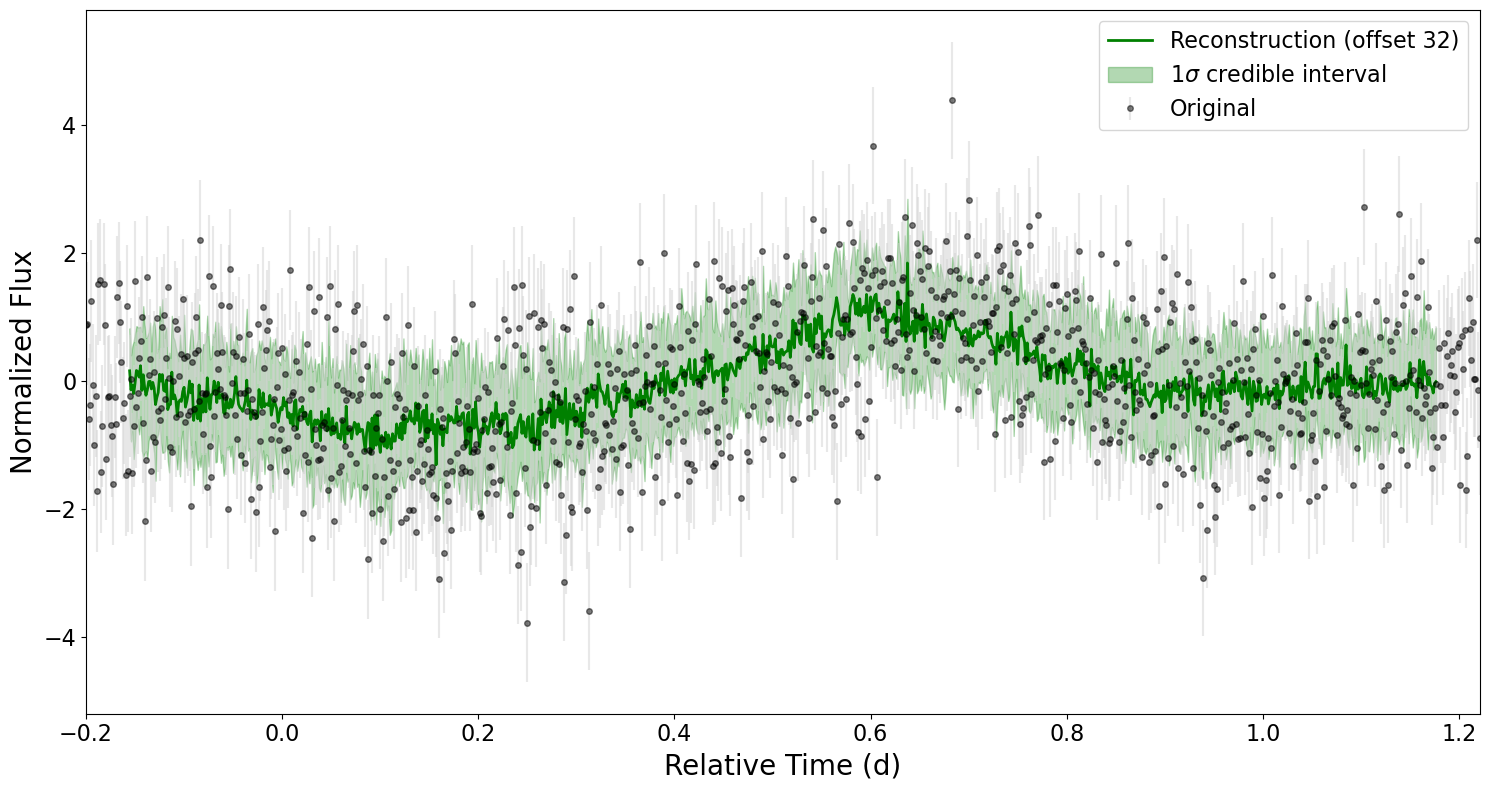

In [75]:

# Try a different seed
plot_reconstruction_for_seed(2,color='green',lags=[32],mask_portion=0)

## Some conceptual demo plots

In [77]:
seed = 2

In [113]:
# Load sample data
ds = TimeSeriesDataset(
        DATA_PATH, random_seed=seed, min_size=0, max_size=0,
        mask_portion=0, max_length=SEQ_LENGTH, num_samples=1
    )
loader = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
flux, flux_err, times, mask = next(iter(loader))
flux, flux_err, times, mask = flux.to(device), flux_err.to(device), times.to(device), mask.to(device)
time_rel = times - times[:, 0].unsqueeze(1)

# Create subset of every hundredth data point for a simple example:
subset_indices = torch.arange(0, flux.size(1), 100)
flux_subset = flux[:, subset_indices].cpu().numpy().flatten()
flux_err_subset = flux_err[:, subset_indices].cpu().numpy().flatten()
times_subset = time_rel[:, subset_indices].cpu().numpy().flatten()

Truncated data to max_length=1024, kept 1/7911 samples.


/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/3550256976.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
/var/folders/lf/sq3cxxf17kv47p5lcv6w5t5r0000gn/T/ipykernel_42053/3550256976.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)


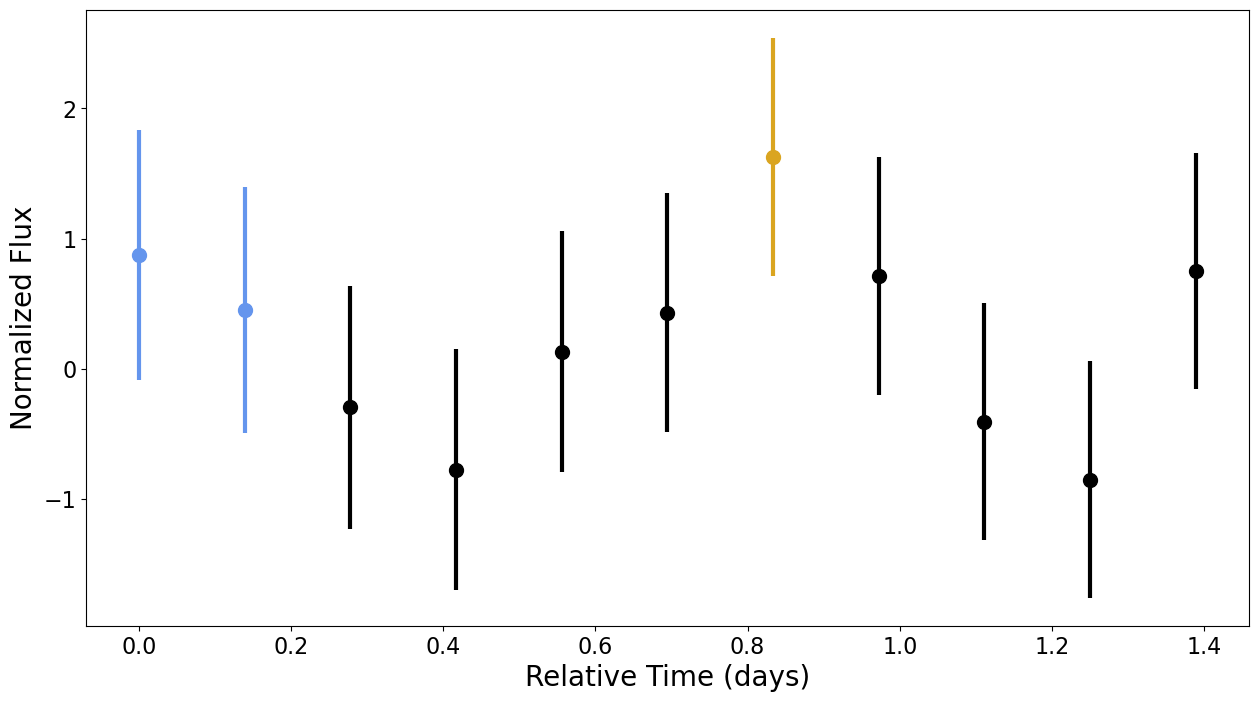

In [180]:
N_train = 2
N_train_bwd = 0
targets = [7]

# Make array of colors for each input point
colors = ['black'] * len(flux_subset)
for i in range(N_train):
    colors[i] = 'cornflowerblue'

for j in range(N_train_bwd):
    colors[len(colors)-1-j] = 'cornflowerblue'

for target in targets:
    colors[target-1] = 'goldenrod'

fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGHEIGHT))

for i in range(len(flux_subset)):
    ax.errorbar(
        times_subset[i], 
        flux_subset[i], 
        yerr=flux_err_subset[i], 
        fmt='.', color=colors[i], alpha=1,
        elinewidth=3,
        markersize=20
    )

plt.ylabel('Normalized Flux', fontsize=20)
plt.xlabel('Relative Time (days)', fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=16)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
plt.show()

## Posterior example

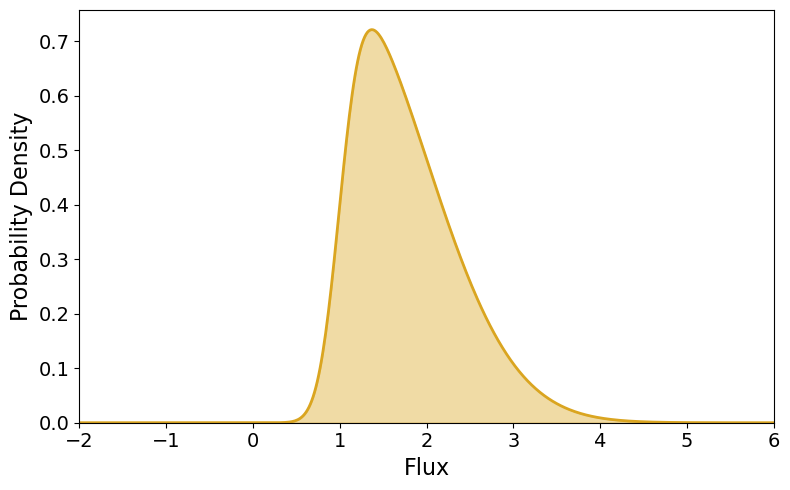

In [143]:
# Plot an arbitrary non-Gaussian unimodal posterior (e.g., skewed)
from scipy.stats import skewnorm

x = np.linspace(-2, 6, 500)
# Skew-normal distribution: a > 0 gives right skew
a = 5  # skewness parameter
loc = 1
scale = 1
pdf = skewnorm.pdf(x, a, loc=loc, scale=scale)

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(x, pdf, alpha=0.4, color='goldenrod')
ax.plot(x, pdf, color='goldenrod', linewidth=2)
ax.set_xlabel('Flux', fontsize=16)
ax.set_ylabel('Probability Density', fontsize=16)
# ax.set_title('Example Posterior Distribution', fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlim(x[0], x[-1])
ax.set_ylim(0, None)
plt.tight_layout()
plt.show()

## Interpolated Reconstruction

Plot reconstructions with predictions at interpolated times (higher temporal resolution).

In [171]:
def plot_reconstruction_interpolated(seed, color='goldenrod', lags=LAGS, flow_mode=FLOW_MODE,
                                      min_size=MIN_SIZE, max_size=MAX_SIZE, mask_portion=MASK_PORTION,
                                      interp_factor=3, n_samples=32, xlim=None):
    """
    Load a lightcurve and plot reconstruction with interpolated time predictions.
    
    For interpolated times, uses the nearest available hidden states:
    - Forward hidden from the last observation before the interpolated time
    - Backward hidden from the first observation after the interpolated time
    
    Args:
        seed: Random seed for data loading
        color: Color for prediction lines
        lags: List of lag offsets to plot
        flow_mode: 'mean', 'mode', or 'sample'
        min_size, max_size: Size range for masking
        mask_portion: Fraction of data to mask
        interp_factor: Factor to increase temporal resolution (e.g., 3 = 3x more time points)
        n_samples: Number of samples for flow mean estimation
        xlim: Optional (xmin, xmax) tuple for x-axis limits
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    # Load data
    ds = TimeSeriesDataset(
        DATA_PATH, random_seed=seed, min_size=min_size, max_size=max_size,
        mask_portion=mask_portion, max_length=SEQ_LENGTH, num_samples=1
    )
    loader = DataLoader(ds, batch_size=1, shuffle=False, collate_fn=collate_fn)
    flux, flux_err, times, mask = next(iter(loader))
    flux, flux_err, times, mask = flux.to(device), flux_err.to(device), times.to(device), mask.to(device)
    
    # Run model on original data to get hidden states
    x_in = torch.stack([flux, flux_err], dim=-1)
    t_in = torch.stack([times], dim=-1)
    
    with torch.no_grad():
        out = model(x_in, t_in, mask=mask, return_states=True, flow_mode=flow_mode)
    
    h_fwd = out.get('h_fwd_tensor')  # (B, L, H)
    h_bwd = out.get('h_bwd_tensor')  # (B, L, H)
    
    B, L, H = h_fwd.shape
    
    # Create interpolated time grid
    times_np = times.cpu().numpy()[0]
    times_rel = times_np - times_np[0]
    flux_err_np = flux_err.cpu().numpy()[0]
    
    # Create finer time grid
    times_interp = np.linspace(times_rel[0], times_rel[-1], L * interp_factor)
    L_interp = len(times_interp)
    
    # For each interpolated time, find the index of the last original observation before it
    # searchsorted gives the index where the value would be inserted to maintain order
    # So for time t between times_rel[i] and times_rel[i+1], searchsorted returns i+1
    # We want i (the last observation before), so we subtract 1 and clip
    insert_indices = np.searchsorted(times_rel, times_interp, side='right')
    # last_obs_before[j] = index of last original observation at or before times_interp[j]
    last_obs_before = np.clip(insert_indices - 1, 0, L - 1)
    # first_obs_after[j] = index of first original observation after times_interp[j]
    first_obs_after = np.clip(insert_indices, 0, L - 1)
    
    # Interpolate flux_err for the flow head context (this is fine to interpolate)
    from scipy.interpolate import interp1d
    f_err = interp1d(times_rel, flux_err_np, kind='linear', fill_value='extrapolate')
    flux_err_interp = torch.tensor(f_err(times_interp), dtype=torch.float32, device=device).unsqueeze(0)
    
    # Compute time encodings for interpolated times
    times_interp_t = torch.tensor(times_interp, dtype=torch.float32, device=device).unsqueeze(0)
    t_shifted_interp = times_interp_t.unsqueeze(-1)
    with torch.no_grad():
        t_enc_interp = model.time_enc(t_shifted_interp)
    
    Te = t_enc_interp.size(-1)
    flow_head = getattr(model, 'flow', None)
    head = model.gauss_head
    
    preds_interp = {}
    preds_interp_p16 = {}
    preds_interp_p84 = {}
    
    with torch.no_grad():
        for k in lags:
            preds_k = torch.full((1, L_interp), float('nan'), device=device)
            preds_p16_k = torch.full((1, L_interp), float('nan'), device=device)
            preds_p84_k = torch.full((1, L_interp), float('nan'), device=device)
            
            # For each interpolated position, determine which hidden states to use
            # Forward: use h_fwd at (last_obs_before - k + 1), needs info up to that point
            # Backward: use h_bwd at (first_obs_after + k), needs info from that point onward
            
            valid_mask = np.zeros(L_interp, dtype=bool)
            fwd_indices = []
            bwd_indices = []
            tgt_indices = []
            
            for j in range(L_interp):
                fwd_idx = last_obs_before[j] - k + 1  # Index for forward hidden
                bwd_idx = first_obs_after[j] + k      # Index for backward hidden
                
                # Check validity: both indices must be in bounds
                if fwd_idx >= 0 and bwd_idx < L:
                    valid_mask[j] = True
                    fwd_indices.append(fwd_idx)
                    bwd_indices.append(bwd_idx)
                    tgt_indices.append(j)
            
            if len(tgt_indices) == 0:
                preds_interp[k] = preds_k.cpu().numpy()
                continue
            
            fwd_indices = torch.tensor(fwd_indices, device=device)
            bwd_indices = torch.tensor(bwd_indices, device=device)
            tgt_indices_t = torch.tensor(tgt_indices, device=device)
            
            # Gather hidden states
            src_f = h_fwd[0, fwd_indices, :]  # (n_valid, H)
            src_b = h_bwd[0, bwd_indices, :]  # (n_valid, H)
            tgt = t_enc_interp[0, tgt_indices_t, :]  # (n_valid, Te)
            
            inputs_k = torch.cat([src_f, src_b, tgt], dim=-1).unsqueeze(0)  # (1, n_valid, dim)
            flat_in = inputs_k.view(-1, inputs_k.size(-1))
            
            # Apply head normalization and time scaling
            normed = model.head_norm(flat_in)
            nt = Te
            if nt > 0:
                h_hidden = normed[:, :-nt]
                h_time = normed[:, -nt:] * model.time_scale
                normed = torch.cat([h_hidden, h_time], dim=1)
            
            # Get flux error at target positions
            ferr_flat = flux_err_interp[0, tgt_indices_t].view(-1, 1)
            
            if flow_head is not None:
                ctx = torch.cat([normed, ferr_flat], dim=1)
                dist = flow_head(ctx)
                
                if flow_mode == 'sample':
                    flat_preds = dist.sample().squeeze(-1)
                elif flow_mode == 'mode':
                    y_init = dist.sample().clone()
                    y_opt = y_init.requires_grad_(True)
                    optimizer = torch.optim.Adam([y_opt], lr=0.1)
                    for _ in range(50):
                        optimizer.zero_grad()
                        loss = -dist.log_prob(y_opt).sum()
                        loss.backward()
                        optimizer.step()
                        with torch.no_grad():
                            y_opt.clamp_(-10, 10)
                    flat_preds = y_opt.detach().squeeze(-1)
                else:  # 'mean'
                    samples = torch.stack([dist.sample() for _ in range(n_samples)], dim=0)
                    samples = samples.squeeze(-1)  # (n_samples, n_valid)
                    flat_preds = samples.mean(dim=0)
                    p16 = torch.quantile(samples, 0.16, dim=0)
                    p84 = torch.quantile(samples, 0.84, dim=0)
                    preds_p16_k[0, tgt_indices_t] = p16
                    preds_p84_k[0, tgt_indices_t] = p84
            else:
                flat_preds = head(normed).squeeze(-1)
            
            preds_k[0, tgt_indices_t] = flat_preds
            
            preds_interp[k] = preds_k.cpu().numpy()
            preds_interp_p16[k] = preds_p16_k.cpu().numpy()
            preds_interp_p84[k] = preds_p84_k.cpu().numpy()
    
    # Convert original data to numpy for plotting
    flux_np = flux.cpu().numpy()
    flux_err_np_orig = flux_err.cpu().numpy()
    mask_np = mask.cpu().numpy()
    
    # Plot
    masked_positions = (mask_np[0] == 0)
    intervals = mask_intervals(masked_positions)
    
    fig, ax = plt.subplots(figsize=(FIGWIDTH, FIGHEIGHT))
    
    # Plot original data with errorbars
    ax.errorbar(times_rel, flux_np[0], yerr=flux_err_np_orig[0], fmt='.', 
                markersize=20,
                label='Original', alpha=DATA_ALPHA, color=DATA_COLOR, ecolor=ERROR_COLOR)
    
    # Plot interpolated predictions
    first_fill = True
    for idx, k in enumerate(lags):
        pred_k = preds_interp.get(k)
        if pred_k is None:
            continue
        ax.plot(times_interp, pred_k[0], label=f'Reconstruction (offset {k})', color=color,
                linewidth=PRED_LINEWIDTH,marker='.',markersize=18)
        pred_p16 = preds_interp_p16.get(k)
        pred_p84 = preds_interp_p84.get(k)
        if pred_p16 is not None and pred_p84 is not None:
            fill_label = r'1$\sigma$ credible interval' if first_fill else None
            ax.fill_between(times_interp, pred_p16[0], pred_p84[0], color=color, alpha=0.3, label=fill_label)
            first_fill = False
    
    # Highlight masked regions
    for start, end in intervals:
        x0 = times_rel[start]
        x1 = times_rel[end-1] if end > start else x0
        ax.axvspan(x0, x1, color=MASK_COLOR, alpha=MASK_ALPHA, label='Masked' if start == intervals[0][0] else None)
    
    ax.set_xlabel('Relative Time (d)', fontsize=20)
    ax.set_ylabel('Normalized Flux', fontsize=20)
    ax.tick_params(axis='both', labelsize=16)
    if xlim is not None:
        ax.set_xlim(xlim)
    else:
        ax.set_xlim(times_interp[0], times_interp[-1])
    ax.set_ylim(-4,2)
    ax.legend(fontsize=16)
    plt.tight_layout()
    plt.show()

Truncated data to max_length=1024, kept 1/7911 samples.


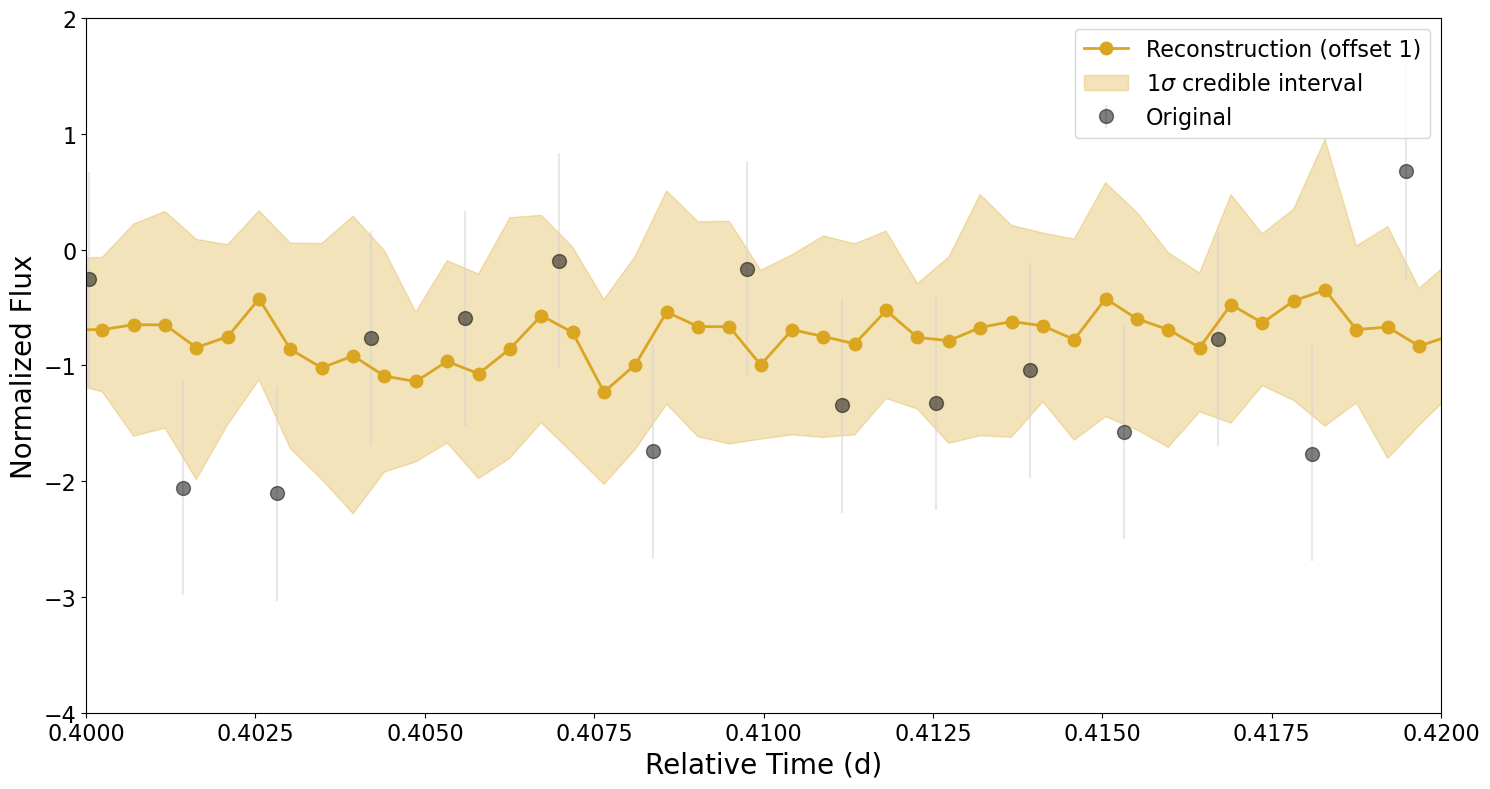

In [172]:
# Example: plot interpolated reconstruction with 3x temporal resolution
plot_reconstruction_interpolated(2, color='goldenrod', lags=[1], mask_portion=0, interp_factor=3, xlim=(0.4,0.42))